In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# LOAD DATA
# -----------------------------
df = pd.read_csv(
    "/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/canarywharf_r10_2025-03_04.csv"
)

In [4]:
df = df[df['type'] == 'stop']

In [5]:
df['ts'].head()

0     1743382001
3     1742873344
5     1743333966
8     1743053391
13    1743417802
Name: ts, dtype: int64

In [6]:
# TIME PROCESSING
# -----------------------------
df['ts'] = pd.to_datetime(df['ts'], unit='s')
df['date'] = df['ts'].dt.date
df['hour'] = df['ts'].dt.hour

In [7]:
df['ts'].head()

0    2025-03-31 00:46:41
3    2025-03-25 03:29:04
5    2025-03-30 11:26:06
8    2025-03-27 05:29:51
13   2025-03-31 10:43:22
Name: ts, dtype: datetime64[ns]

*without duration*

In [8]:
# NIGHTTIME FILTER (7 PM – 7 AM)
# -----------------------------
night_df = df[(df['hour'] >= 19) | (df['hour'] < 7)]

In [9]:
# COUNT UNIQUE NIGHTS 
# -----------------------------
resident_counts = (
    night_df.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

In [10]:
# FINAL RESIDENT FILTER
# -----------------------------
residents_5 = resident_counts[resident_counts['nights'] >= 5]['id']
print("Likely residents >=5:", len(residents_5))

residents_4 = resident_counts[resident_counts['nights'] >= 4]['id']
print("Likely residents >=4:", len(residents_4))

residents_3 = resident_counts[resident_counts['nights'] >= 3]['id']
print("Likely residents >=3:", len(residents_3))

residents_2 = resident_counts[resident_counts['nights'] >= 2]['id']
print("Likely residents >=2:", len(residents_2))


Likely residents >=5: 4568
Likely residents >=4: 6788
Likely residents >=3: 11307
Likely residents >=2: 23286


*with duration*

In [11]:
# -----------------------------
# DURATION CALCULATION (ADD-ON)
# -----------------------------

duration_df = (
    night_df.groupby(['id', 'date'])
    .agg(
        start_time=('ts', 'min'),
        end_time=('ts', 'max'),
        num_points=('ts', 'count')
    )
    .reset_index()
)

duration_df['duration_hours'] = (
    duration_df['end_time'] - duration_df['start_time']
).dt.total_seconds() / 3600

In [12]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 2
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_5_dur2 = resident_counts_dur[resident_counts_dur['nights'] >= 5]['id']
print("users with at least 2 observations per night across at least 5 nights:", len(residents_5_dur2))

users with at least 2 observations per night across at least 5 nights: 3107


In [13]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 3
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_5_dur3 = resident_counts_dur[resident_counts_dur['nights'] >= 5]['id']
print("users with at least 3 observations per night across at least 5 nights:", len(residents_5_dur3))

users with at least 3 observations per night across at least 5 nights: 2307


In [14]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 2
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_7_dur2 = resident_counts_dur[resident_counts_dur['nights'] >= 7]['id']
print("users with at least 2 observations per night across at least 7 nights:", len(residents_7_dur2))

users with at least 2 observations per night across at least 7 nights: 1679


In [15]:
duration_filtered = duration_df[
    duration_df['num_points'] >= 3
]

resident_counts_dur = (
    duration_filtered.groupby('id')['date']
    .nunique()
    .reset_index(name='nights')
)

residents_7_dur3 = resident_counts_dur[resident_counts_dur['nights'] >= 7]['id']
print("users with at least 3 observations per night across at least 7 nights:", len(residents_7_dur3))

users with at least 3 observations per night across at least 7 nights: 1237


*duration per week, hrs per night*

In [16]:
duration_df['night_date'] = duration_df['date']

duration_df.loc[duration_df['start_time'].dt.hour < 7, 'night_date'] = (
    duration_df['night_date'] - pd.Timedelta(days=1))

In [17]:
duration_df['week'] = pd.to_datetime(duration_df['night_date']).dt.to_period('W')

# Parameters to test
hour_thresholds = [5, 7]
night_thresholds = [2, 3]

for hrs in hour_thresholds:
    for nights in night_thresholds:
        
        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]
        
        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )
        
        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        
        # unique users
        users = weekly_valid['id'].unique()
        
        print(f"Users ≥{hrs}hrs/night & ≥{nights} nights/week:", len(users))

Users ≥5hrs/night & ≥2 nights/week: 1557
Users ≥5hrs/night & ≥3 nights/week: 508
Users ≥7hrs/night & ≥2 nights/week: 1385
Users ≥7hrs/night & ≥3 nights/week: 447


In [18]:
duration_df['week'] = pd.to_datetime(duration_df['night_date']).dt.to_period('W')

# Parameters to test
hour_thresholds = [2,5,7]
night_thresholds = [2, 3]

for hrs in hour_thresholds:
    for nights in night_thresholds:
        
        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]
        
        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )
        
        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        
        # unique users
        users = weekly_valid['id'].unique()
        
        print(f"Users ≥{hrs}hrs/night & ≥{nights} nights/week:", len(users))

Users ≥2hrs/night & ≥2 nights/week: 2814
Users ≥2hrs/night & ≥3 nights/week: 875
Users ≥5hrs/night & ≥2 nights/week: 1557
Users ≥5hrs/night & ≥3 nights/week: 508
Users ≥7hrs/night & ≥2 nights/week: 1385
Users ≥7hrs/night & ≥3 nights/week: 447


In [19]:
duration_df['week'] = pd.to_datetime(duration_df['night_date']).dt.to_period('W')

# Parameters to test
hour_thresholds = [3, 5, 7]
night_thresholds = [2, 3]

for hrs in hour_thresholds:
    for nights in night_thresholds:
        
        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]
        
        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )
        
        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        
        # unique users
        users = weekly_valid['id'].unique()
        
        print(f"Users ≥{hrs}hrs/night & ≥{nights} nights/week:", len(users))

Users ≥3hrs/night & ≥2 nights/week: 2153
Users ≥3hrs/night & ≥3 nights/week: 700
Users ≥5hrs/night & ≥2 nights/week: 1557
Users ≥5hrs/night & ≥3 nights/week: 508
Users ≥7hrs/night & ≥2 nights/week: 1385
Users ≥7hrs/night & ≥3 nights/week: 447


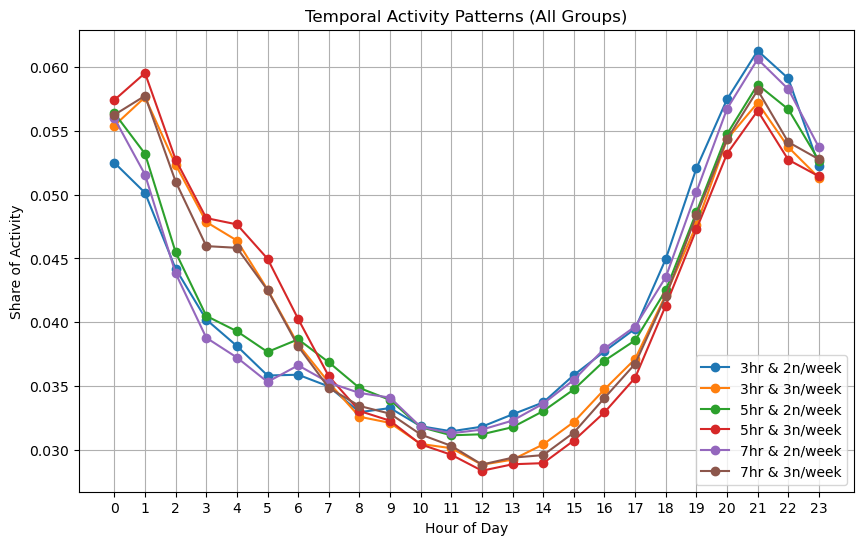

In [20]:
import matplotlib.pyplot as plt

# parameters
hour_thresholds = [3, 5, 7]
night_thresholds = [2, 3]

plt.figure(figsize=(10,6))

for hrs in hour_thresholds:
    for nights in night_thresholds:

        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]

        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )

        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]

        # get users
        users = weekly_valid['id'].unique()

        # filter original data
        temp_df = df[df['id'].isin(users)]

        # hourly activity
        hourly = (
            temp_df.groupby('hour')
            .size()
            .reset_index(name='count')
        )

        # normalize
        hourly['normalized'] = hourly['count'] / hourly['count'].sum()

        # label
        label = f"{hrs}hr & {nights}n/week"

        plt.plot(hourly['hour'], hourly['normalized'], marker='o', label=label)

# plot settings
plt.xlabel("Hour of Day")
plt.ylabel("Share of Activity")
plt.title("Temporal Activity Patterns (All Groups)")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)
plt.show()

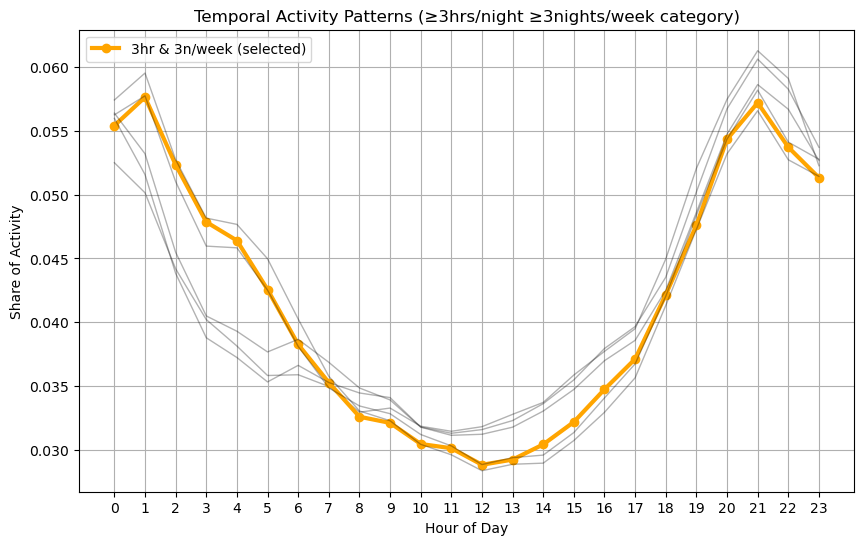

In [30]:
import matplotlib.pyplot as plt

# parameters
hour_thresholds = [3, 5, 7]
night_thresholds = [2, 3]

plt.figure(figsize=(10,6))

for hrs in hour_thresholds:
    for nights in night_thresholds:

        # filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]

        # count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )

        # apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]

        # get users
        users = weekly_valid['id'].unique()

        # filter original data
        temp_df = df[df['id'].isin(users)]

        # hourly activity
        hourly = (
            temp_df.groupby('hour')
            .size()
            .reset_index(name='count')
        )

        # normalize
        hourly['normalized'] = hourly['count'] / hourly['count'].sum()

        # -----------------------------------
        # STYLE: highlight only 3hr & 3 nights
        # -----------------------------------
        if hrs == 3 and nights == 3:
            plt.plot(
                hourly['hour'],
                hourly['normalized'],
                marker='o',
                color='orange',
                linewidth=3,
                label="3hr & 3n/week (selected)"
            )
        else:
            plt.plot(
                hourly['hour'],
                hourly['normalized'],
                color='black',
                alpha=0.3,
                linewidth=1
            )

# plot settings
plt.xlabel("Hour of Day")
plt.ylabel("Share of Activity")
plt.title("Temporal Activity Patterns (≥3hrs/night ≥3nights/week category)")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)

plt.show()

In [21]:
!pip install matplotlib-venn

Defaulting to user installation because normal site-packages is not writeable


In [22]:
user_sets = {}

for hrs in [2, 7]:
    for nights in [2, 3]:

        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]

        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )

        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        users = set(weekly_valid['id'].unique())

        key = f"{hrs}hr_{nights}n"
        user_sets[key] = users

In [23]:
set1 = user_sets['7hr_2n']
set2 = user_sets['2hr_3n']
set3 = user_sets['7hr_3n']

In [24]:
# define sets
A = user_sets['7hr_2n']
B = user_sets['2hr_3n']
C = user_sets['7hr_3n']

# sizes
print("A (7hr & 2n):", len(A))
print("B (2hr & 3n):", len(B))
print("C (7hr & 3n):", len(C))

# overlaps
print("A ∩ B:", len(A & B))
print("A ∩ C:", len(A & C))
print("B ∩ C:", len(B & C))
print("A ∩ B ∩ C:", len(A & B & C))

A (7hr & 2n): 1385
B (2hr & 3n): 875
C (7hr & 3n): 447
A ∩ B: 688
A ∩ C: 447
B ∩ C: 447
A ∩ B ∩ C: 447


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import from_contents, plot

# 1. Setup Data Storage
all_groups = {}
hour_thresholds = [2, 5, 7]
night_thresholds = [2, 3]

# Ensure week is calculated
duration_df['week'] = pd.to_datetime(duration_df['night_date']).dt.to_period('W')

# 2. Run the Loop to Populate Groups
for hrs in hour_thresholds:
    for nights in night_thresholds:
        
        # Filter duration + reliability
        temp = duration_df[
            (duration_df['duration_hours'] >= hrs) &
            (duration_df['num_points'] >= 2)
        ]
        
        # Count nights per week
        weekly = (
            temp.groupby(['id', 'week'])['night_date']
            .nunique()
            .reset_index(name='nights_per_week')
        )
        
        # Apply weekly threshold
        weekly_valid = weekly[weekly['nights_per_week'] >= nights]
        
        # Store unique users as a set for overlap analysis
        users = set(weekly_valid['id'].unique())
        
        # Create a label like "2h_3n" (2 hours, 3 nights)
        group_name = f"{hrs}h_{nights}n"
        all_groups[group_name] = users

# 3. Data Transformation for UpSetPlot
# This converts the dictionary of sets into a format UpSet understands
upset_data = from_contents(all_groups)

# 4. Visualization
# We use a figure size that accounts for 6 groups
plt.figure(figsize=(12, 8))
plot(upset_data, orientation='horizontal', subset_size='count', show_counts=True)

plt.suptitle("User Overlap Across Threshold Groups", fontsize=16)
plt.show()

ModuleNotFoundError: No module named 'upsetplot'

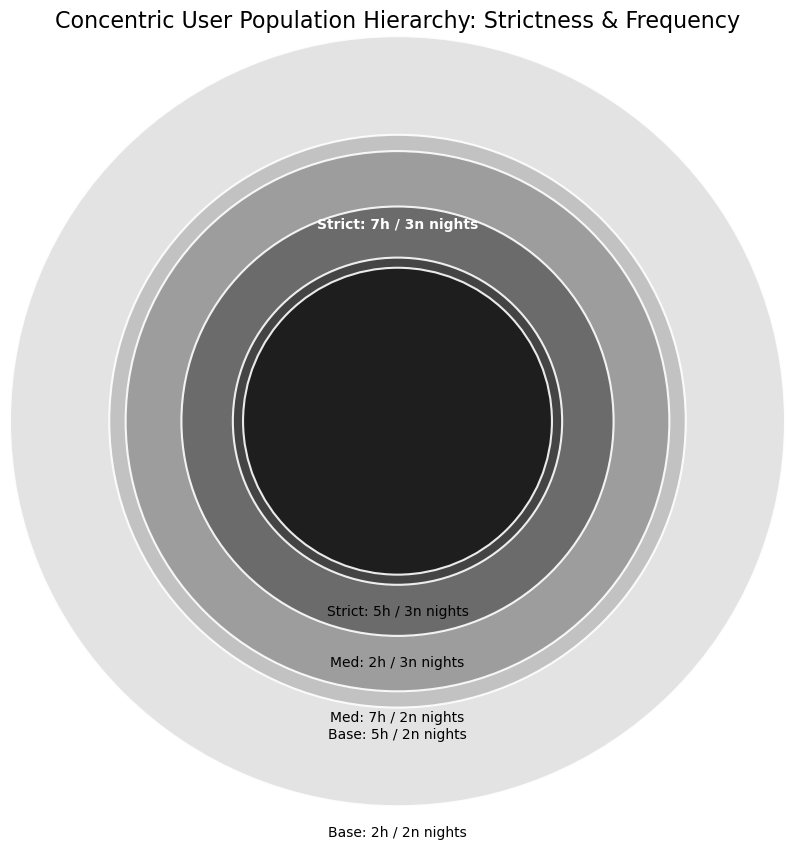

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Data extracted directly from your original result matrix (image_0.png)
# Stored as dictionaries, with the key structure emphasizing the hierarchy:
# Group Key -> [Descriptive Label, Total Set Size, Color]
hierarchy_data = {
    '7h_3n': ['Strict: 7h / 3n nights', 447,  '#1a1a1a'],  # Inner-most
    '5h_3n': ['Strict: 5h / 3n nights', 508,  '#404040'],
    '2h_3n': ['Med: 2h / 3n nights',   875,  '#666666'],
    '7h_2n': ['Med: 7h / 2n nights',   1385, '#999999'],
    '5h_2n': ['Base: 5h / 2n nights',  1557, '#bfbfbf'],
    '2h_2n': ['Base: 2h / 2n nights',  2814, '#e0e0e0']   # Outermost
}

# Parameters for the concentric circles
center_x = 0.5
center_y = 0.5
total_area = 2814  # Size of the outermost 2h_2n group

# --- Generate the simple concentric visualization ---
fig, ax = plt.subplots(figsize=(10, 10))

# Standardize axis to make drawing shapes easier
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')  # Turn off axis labels

# Create the shapes starting from the largest (2h_2n) down to the smallest (7h_3n)
ordered_keys = list(hierarchy_data.keys())[::-1] # Reverse order for layering

for key in ordered_keys:
    label, size, color = hierarchy_data[key]
    
    # Calculate radius based on area-proportional scaling
    # Radius = sqrt(Area / pi), and we scale everything to the total_area
    radius = (size / total_area)**0.5 / 2  # The '/ 2' fits it within the plot

    # Draw the nested circle
    circle = patches.Circle((center_x, center_y), radius, color=color, ec='white', lw=1.5, alpha=0.9)
    ax.add_patch(circle)
    
    # Position the label for the innermost, strictest group differently (on top)
    if key == '7h_3n':
        ax.text(center_x, center_y + (radius + 0.05), label, color='white', ha='center', fontweight='bold')
    else:
        # Position base labels at the bottom edge of their respective rings
        text_y_position = center_y - (radius + 0.04)
        ax.text(center_x, text_y_position, label, color='black', ha='center')

plt.title("Concentric User Population Hierarchy: Strictness & Frequency", fontsize=16)
plt.show()

<Figure size 1000x800 with 0 Axes>

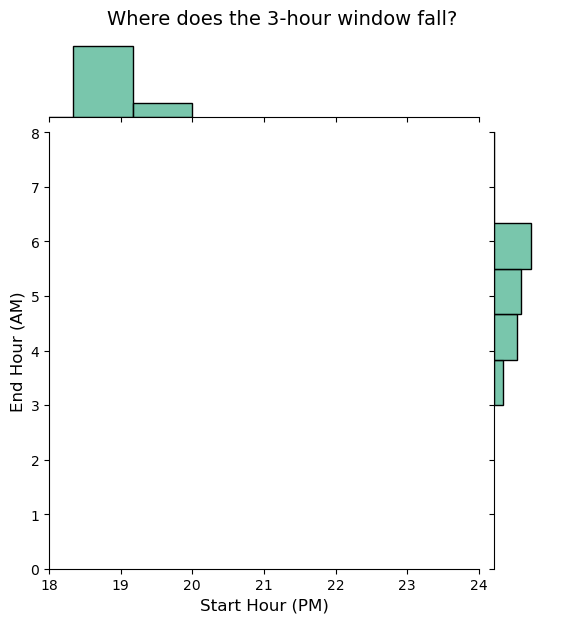

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 筛选出 3 小时组 (例如 3-5 小时)
# 使用 .copy() 确保后续操作不影响原 DataFrame
three_hour_nights = duration_df[
    (duration_df['duration_hours'] >= 3) & 
    (duration_df['duration_hours'] < 5)
].copy()

# 2. 提取小时 (用于横纵坐标)
three_hour_nights['start_hour'] = three_hour_nights['start_time'].dt.hour
three_hour_nights['end_hour'] = three_hour_nights['end_time'].dt.hour

# 3. 创建联合分布图 (Jointplot)
# 我们重点看晚上 7 点到凌晨 7 点的窗口
# 注意：end_hour 如果是凌晨，数值会很小 (0, 1, 2...)，这在坐标轴上很直观
plt.figure(figsize=(10, 8))
g = sns.jointplot(
    data=three_hour_nights, 
    x='start_hour', 
    y='end_hour', 
    kind="hex", 
    color="#4CB391",
    marginal_kws=dict(bins=24, fill=True)
)

# 设置坐标轴范围，聚焦夜间窗口
g.ax_joint.set_xlim(18, 24)
g.ax_joint.set_ylim(0, 8) 
g.set_axis_labels('Start Hour (PM)', 'End Hour (AM)', fontsize=12)

plt.suptitle("Where does the 3-hour window fall?", y=1.03, fontsize=14)
plt.show()

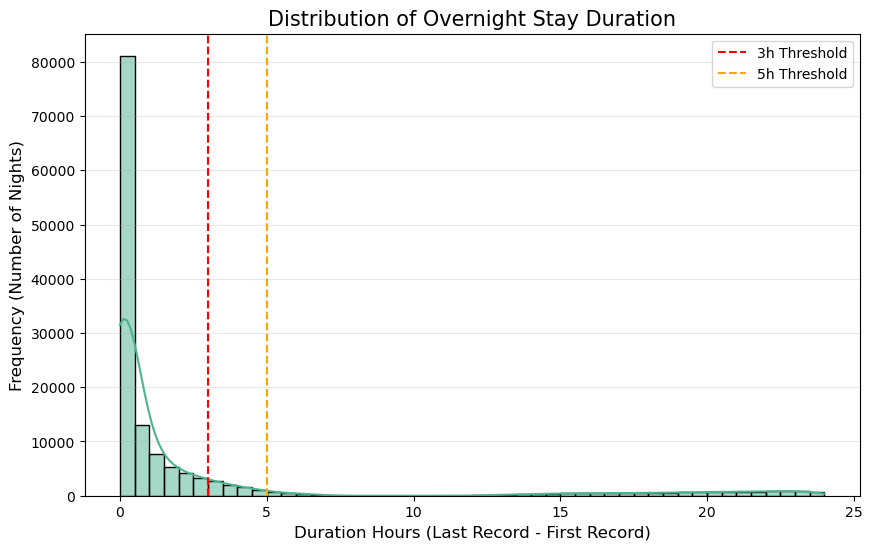

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# 绘制 duration_hours 的分布直方图
sns.histplot(duration_df['duration_hours'], bins=48, kde=True, color='#4CB391')

# 添加参考线
plt.axvline(x=3, color='r', linestyle='--', label='3h Threshold')
plt.axvline(x=5, color='orange', linestyle='--', label='5h Threshold')

plt.title("Distribution of Overnight Stay Duration", fontsize=15)
plt.xlabel("Duration Hours (Last Record - First Record)", fontsize=12)
plt.ylabel("Frequency (Number of Nights)", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()